In [1]:
import numpy as np
import pandas as pd
# процедура стандартизации
from sklearn.preprocessing import StandardScaler
# алгоритм k-средних
from sklearn.cluster import KMeans
# алгоритм k-ближайших соседей
from sklearn.neighbors import KNeighborsClassifier
# дендрограмма
from scipy.cluster.hierarchy import dendrogram, linkage
# дендрограмма, расчет матрицы расстояний
from scipy.spatial.distance import pdist
# метрики
from sklearn.metrics import silhouette_score, adjusted_rand_score
# кластерные силуэты
from matplotlib import cm
from sklearn.metrics import silhouette_samples
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from scipy.optimize import linear_sum_assignment
%matplotlib inline
plt.style.use('ggplot')
sns.set(style="whitegrid")

In [2]:
data = load_breast_cancer()
list(data.target_names)

[np.str_('malignant'), np.str_('benign')]

In [3]:
df = pd.DataFrame(data.data, columns=data.feature_names) #1. загрузка данных, вывод первый пяти строк
df['target'] = data.target
X_base = df[['mean compactness', 'mean concavity']].copy()
X_base.columns = ['Compactness', 'Concavity']
print(X_base.head())

   Compactness  Concavity
0      0.27760     0.3001
1      0.07864     0.0869
2      0.15990     0.1974
3      0.28390     0.2414
4      0.13280     0.1980


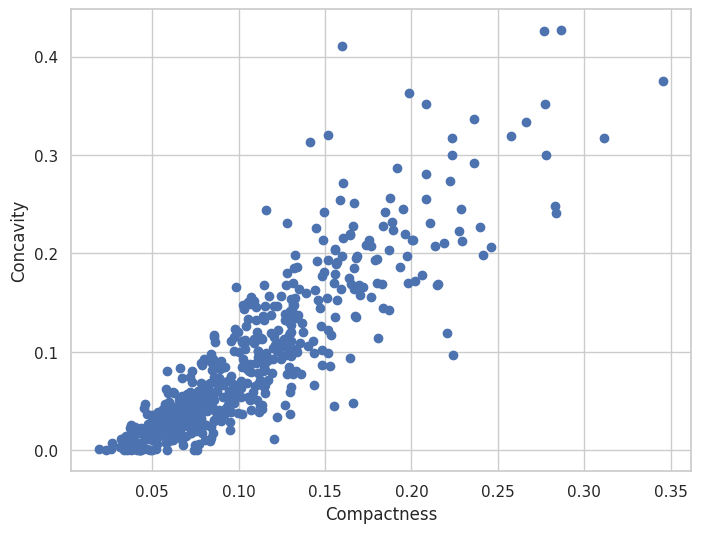

In [4]:
plt.figure(figsize=(8, 6)) #2. диаграмма рассеивания
plt.scatter(X_base['Compactness'], X_base['Concavity'])
plt.xlabel('Compactness')
plt.ylabel('Concavity')
plt.show()

In [5]:
K1 = 2  # на графике видно два облака рассеивания точек, оптимальное кол-во кластеров 2

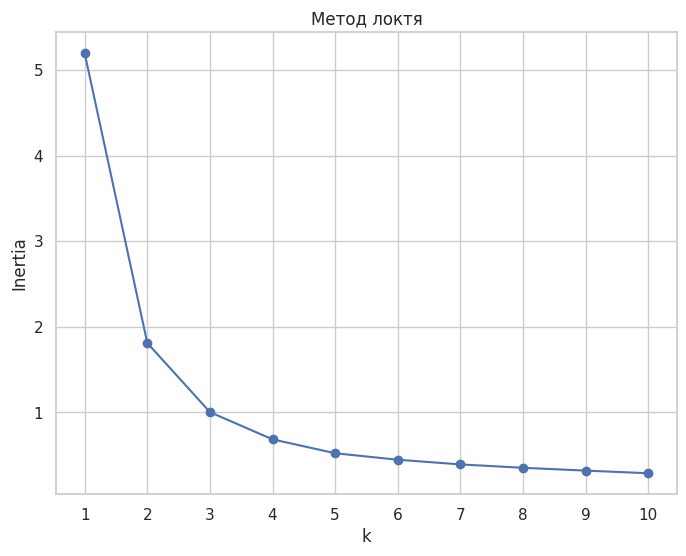

In [6]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_base)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia, 'bo-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Метод локтя')
plt.xticks(K_range)
plt.show()

In [7]:
K2 = 3  # 3. излом на графике происходит при k=3, оптимальное кол-во кластеров равно 3

In [8]:
kmeans_k1 = KMeans(n_clusters=K1, random_state=42, n_init=10)
labels_k1 = kmeans_k1.fit_predict(X_base)
silhouette_k1 = silhouette_score(X_base, labels_k1)

kmeans_k2 = KMeans(n_clusters=K2, random_state=42, n_init=10)
labels_k2 = kmeans_k2.fit_predict(X_base)
silhouette_k2 = silhouette_score(X_base, labels_k2)

print(f"Силуэт для K={K1}: {silhouette_k1:.4f}")
print(f"Силуэт для K={K2}: {silhouette_k2:.4f}")

if silhouette_k1 > silhouette_k2:
    best_k = K1
    best_labels = labels_k1
    best_kmeans = kmeans_k1
else:
    best_k = K2
    best_labels = labels_k2
    best_kmeans = kmeans_k2

print(f"Лучшее разбиение: K = {best_k}, так как имеет наибольший коэффициент, близкий к единице")

Силуэт для K=2: 0.6094
Силуэт для K=3: 0.5453
Лучшее разбиение: K = 2, так как имеет наибольший коэффициент, близкий к единице


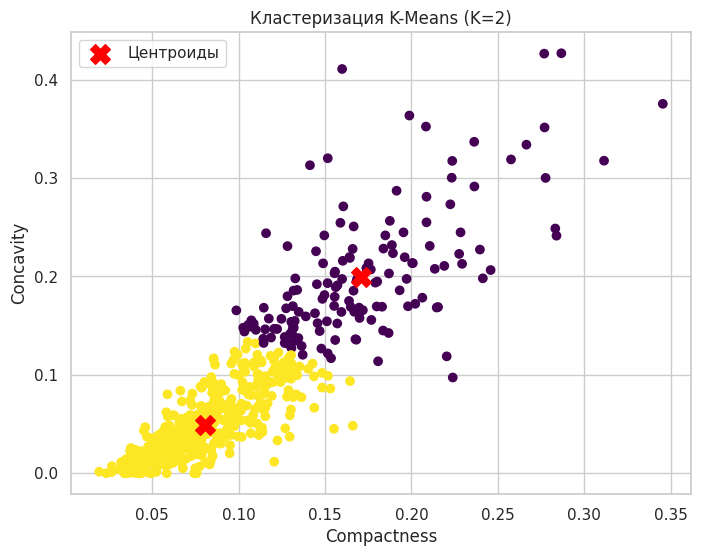

In [9]:
plt.figure(figsize=(8, 6)) #5. строим кластеры и наносим центроиды
plt.scatter(X_base['Compactness'], X_base['Concavity'], c=best_labels, cmap='viridis')
plt.scatter(best_kmeans.cluster_centers_[:, 0], best_kmeans.cluster_centers_[:, 1],
            marker='X', s=200, c='red', label='Центроиды')
plt.title(f'Кластеризация K-Means (K={best_k})')
plt.xlabel('Compactness')
plt.ylabel('Concavity')
plt.legend()
plt.show()

In [10]:
X_full = df[['mean compactness', 'mean concavity', 'mean area']].copy() #6. делим на обучающую и тестовую выборки
X_full.columns = ['Compactness', 'Concavity', 'Area']

X_train, X_test = train_test_split(X_full, test_size=0.2, random_state=42)

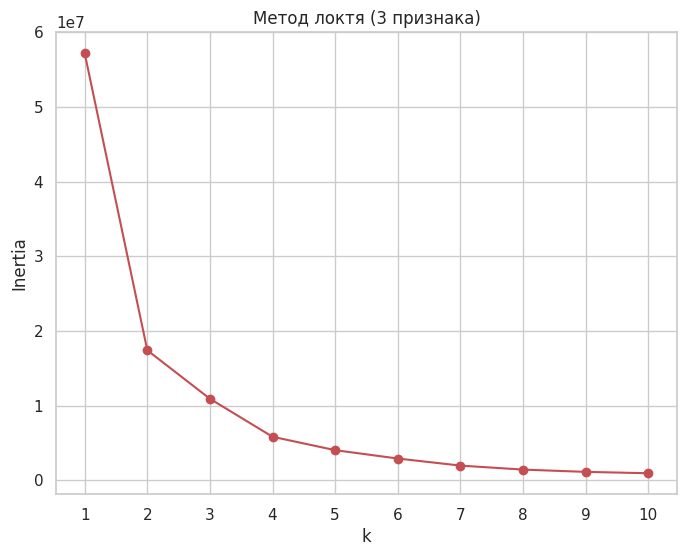

In [11]:
inertia_3d = [] #7. метод локтя для 3 признака
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_train)
    inertia_3d.append(kmeans.inertia_)

plt.figure(figsize=(8, 6))
plt.plot(K_range, inertia_3d, 'ro-')
plt.xlabel('k')
plt.ylabel('Inertia')
plt.title('Метод локтя (3 признака)')
plt.xticks(K_range)
plt.show()

In [12]:
K3 = 2 #перелом при k=2

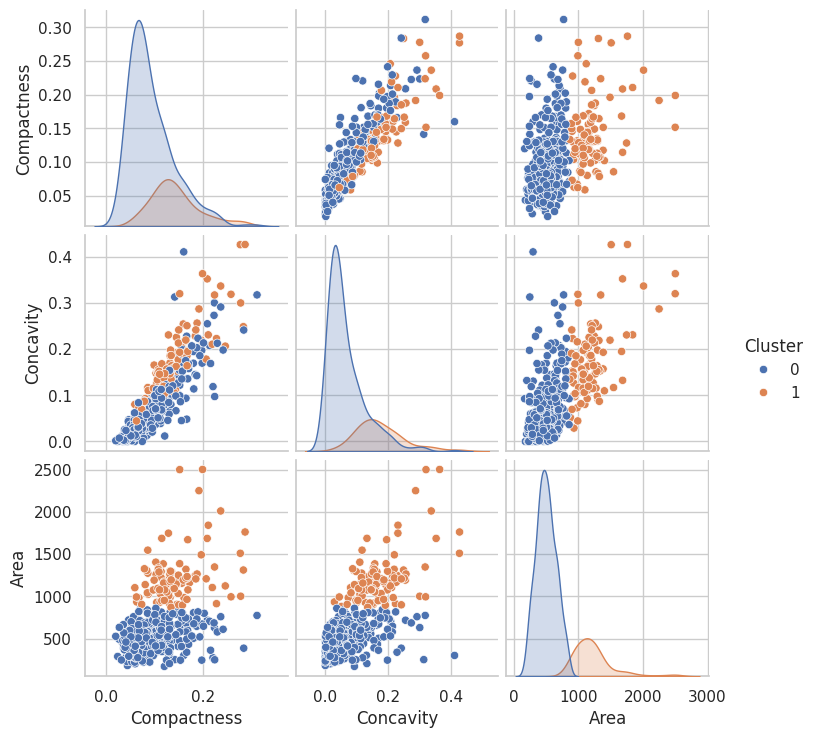

         Compactness  Concavity         Area
Cluster                                     
0           0.092932   0.065587   500.462011
1           0.143062   0.174935  1222.437113


In [13]:
kmeans_final = KMeans(n_clusters=K3, random_state=42, n_init=10) #8. кластеризация для обучающей выборки
train_labels = kmeans_final.fit_predict(X_train)

X_train_with_labels = X_train.copy()
X_train_with_labels['Cluster'] = train_labels

sns.pairplot(X_train_with_labels, vars=['Compactness', 'Concavity', 'Area'],
             hue='Cluster')
plt.show()

print(X_train_with_labels.groupby('Cluster').mean())

In [14]:
predicted_labels = kmeans_final.predict(X_test) #9. прогноз для прогнозной выборки

X_test_with_pred = X_test.copy()
X_test_with_pred['Predicted_Cluster'] = predicted_labels

print(X_test_with_pred.head(10))

     Compactness  Concavity    Area  Predicted_Cluster
204      0.10580    0.08005   481.9                  0
70       0.10290    0.10800  1130.0                  1
131      0.12230    0.14660   748.9                  0
431      0.13160    0.07741   467.8                  0
540      0.11200    0.06737   402.9                  0
567      0.27700    0.35140  1265.0                  1
369      0.19540    0.24480  1482.0                  1
29       0.11570    0.09875   955.1                  1
81       0.15350    0.11690   520.0                  0
477      0.05319    0.02224   599.4                  0


In [15]:
y = df['target']
_, y_test = train_test_split(y, test_size=0.2, random_state=42)


def acc(y_true, y_pred):
    y_true = y_true.astype(np.int64)
    y_pred = y_pred.astype(np.int64)

    D = max(y_pred.max(), y_true.max()) + 1
    w = np.zeros((D, D), dtype=np.int64)

    for i in range(y_pred.size):
        w[y_pred[i], y_true[i]] += 1

    row_ind, col_ind = linear_sum_assignment(w.max() - w)
    return sum([w[row_ind[i], col_ind[i]] for i in range(len(row_ind))]) / y_pred.size

acc_score = acc(y_test.values, predicted_labels)
print(f"ACC: {acc_score:.4f}")

ACC: 0.8421


In [16]:
#полученный Acc означает, что большинство объектов были правильно классифицированы